# JOUR 4 — Réseaux de neurones, Deep Learning & CNN
## Notebook formateur — PyTorch

Ce notebook accompagne le **Support 1** du dernier jour.

### Fil conducteur
**Neurone → MLP → forward → loss → backpropagation → CNN → entraînement → évaluation → transfer learning**

Nous utilisons **CIFAR-10**, un jeu d’images réel et standard de vision par ordinateur, disponible directement avec `torchvision`.

### Objectifs
À la fin, les étudiants doivent savoir :
- reconnaître les tenseurs d’entrée et de sortie ;
- construire un MLP puis un CNN ;
- expliquer `forward()`, la loss, `backward()` et `optimizer.step()` ;
- lire les courbes TRAIN / VALIDATION ;
- interpréter une matrice de confusion ;
- comprendre le principe du transfer learning avec ResNet18.

> **Conseil formateur :** exécuter progressivement. L’objectif n’est pas de lancer immédiatement tout le notebook, mais de faire verbaliser ce que chaque bloc réalise.


In [12]:
# Vérification de l'environnement
import sys
import torch
import torchvision

print("Python      :", sys.version.split()[0])
print("PyTorch     :", torch.__version__)
print("Torchvision :", torchvision.__version__)
print("GPU CUDA    :", torch.cuda.is_available())


Python      : 3.14.6
PyTorch     : 2.14.0
Torchvision : 0.29.0
GPU CUDA    : False


### Explication du code

**`import sys`** permet d'accéder à des informations sur l'environnement Python.

**`import torch`** charge PyTorch, la bibliothèque qui va gérer les tenseurs, les réseaux de neurones, le calcul automatique des gradients et l'entraînement.

**`import torchvision`** charge les outils spécialisés dans la vision : datasets, transformations d'images et modèles pré-entraînés.

**`torch.cuda.is_available()`** vérifie si PyTorch peut utiliser un GPU NVIDIA avec CUDA.

### Pourquoi le vérifier ?
Un réseau de neurones peut fonctionner sur CPU, mais l'entraînement des CNN devient beaucoup plus rapide sur GPU.

### À retenir
Le code PyTorch restera presque identique entre CPU et GPU : c'est principalement le **device** qui change.


In [13]:
# Imports principaux
import numpy as np
import matplotlib.pyplot as plt

from torch import nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

torch.manual_seed(42)
np.random.seed(42)


### Explication du code

**`numpy`** sert aux opérations numériques complémentaires.

**`matplotlib.pyplot`** sert à afficher les images et les courbes d'apprentissage.

**`nn`** contient les briques des réseaux de neurones : `Linear`, `Conv2d`, `ReLU`, `MaxPool2d`, etc.

**`DataLoader`** crée les mini-batches utilisés pendant l'entraînement.

**`random_split`** permet de séparer le TRAIN en TRAIN et VALIDATION.

**`datasets`** donne accès à CIFAR-10.

**`transforms`** définit les transformations appliquées aux images.

Les fonctions de `sklearn.metrics` serviront à analyser les prédictions finales.

Enfin, les seeds fixées à `42` améliorent la reproductibilité de l'expérience.


# 1. Choisir le device

PyTorch doit savoir où stocker les tenseurs et exécuter les calculs.


In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device utilisé :", device)


Device utilisé : cpu


### Explication

Si CUDA est disponible, `device` devient `cuda`. Sinon, il devient `cpu`.

Plus tard, lorsque nous écrirons :

`model.to(device)`

nous déplacerons les paramètres du réseau vers ce device.

Et avec :

`images.to(device)`

nous déplacerons également les données.

### Point important
Le modèle **et** les données utilisées dans une opération doivent être sur le même device.


# 2. Charger CIFAR-10

CIFAR-10 contient des images couleur de taille **32 × 32** réparties en **10 classes**.

Nous commençons volontairement par une transformation simple : conversion en tenseur + normalisation.


In [17]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

In [18]:
train_full = datasets.CIFAR10(
    root=r"../data/cifar-10-python",
    train=True,
    download=False,
    transform=transform
)

test_dataset = datasets.CIFAR10(
    root=r"../data/cifar-10-python",
    train=False,
    download=False,
    transform=transform
)

classes = train_full.classes

print("TRAIN complet :", len(train_full))
print("TEST          :", len(test_dataset))
print("Classes       :", classes)

TRAIN complet : 50000
TEST          : 10000
Classes       : ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


### Explication ligne par ligne

**`transforms.Compose([...])`** construit une chaîne de transformations.

**`ToTensor()`** convertit l'image en tenseur PyTorch et organise les dimensions sous la forme :

`[channels, height, width]`

Pour CIFAR-10 : **`[3, 32, 32]`**.

Les trois canaux correspondent à Rouge, Vert et Bleu.

**`Normalize(mean, std)`** centre et réduit approximativement chaque canal. Cela facilite généralement l'optimisation.

**`datasets.CIFAR10(..., train=True)`** charge les images d'entraînement.

**`download=True`** télécharge automatiquement le dataset s'il n'est pas encore présent dans `./data`.

Le TEST officiel est chargé séparément avec `train=False`.

### Pourquoi ne pas utiliser TEST pour choisir le modèle ?
TEST doit rester indépendant jusqu'à l'évaluation finale. Nous allons donc créer VALIDATION à partir du TRAIN.


# 3. Créer TRAIN / VALIDATION / TEST


In [19]:
n_total = len(train_full)
n_train = int(0.80 * n_total)
n_val = n_total - n_train

generator = torch.Generator().manual_seed(42)

train_dataset, val_dataset = random_split(
    train_full,
    [n_train, n_val],
    generator=generator
)

print("TRAIN :", len(train_dataset))
print("VALID :", len(val_dataset))
print("TEST  :", len(test_dataset))


TRAIN : 40000
VALID : 10000
TEST  : 10000


### Explication

Nous gardons le TEST officiel intact.

Le jeu d'entraînement original est séparé en :
- **80 % TRAIN** : apprentissage des poids ;
- **20 % VALIDATION** : suivi de la généralisation et choix du modèle.

`torch.Generator().manual_seed(42)` rend le split reproductible.

### Rappel anti-leakage
TRAIN apprend. VALIDATION aide à décider. TEST évalue une seule fois à la fin.


# 4. Construire les DataLoaders

Le réseau n'apprend généralement pas sur toutes les images simultanément. Il travaille par **mini-batches**.


In [20]:
batch_size = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

images, labels = next(iter(train_loader))

print("Shape images :", images.shape)
print("Shape labels :", labels.shape)


Shape images : torch.Size([128, 3, 32, 32])
Shape labels : torch.Size([128])


### Comment lire `torch.Size([128, 3, 32, 32])` ?

- `128` : nombre d'images du mini-batch ;
- `3` : canaux RGB ;
- `32` : hauteur ;
- `32` : largeur.

Les labels ont une dimension `[128]` : une classe entière par image.

### Pourquoi `shuffle=True` uniquement sur TRAIN ?
Nous mélangeons TRAIN pour éviter que l'ordre des observations influence les mini-batches. Pour VALIDATION et TEST, le mélange n'est pas nécessaire.


# 5. Visualiser quelques images

Comme les images ont été normalisées, nous devons approximativement inverser la normalisation avant affichage.


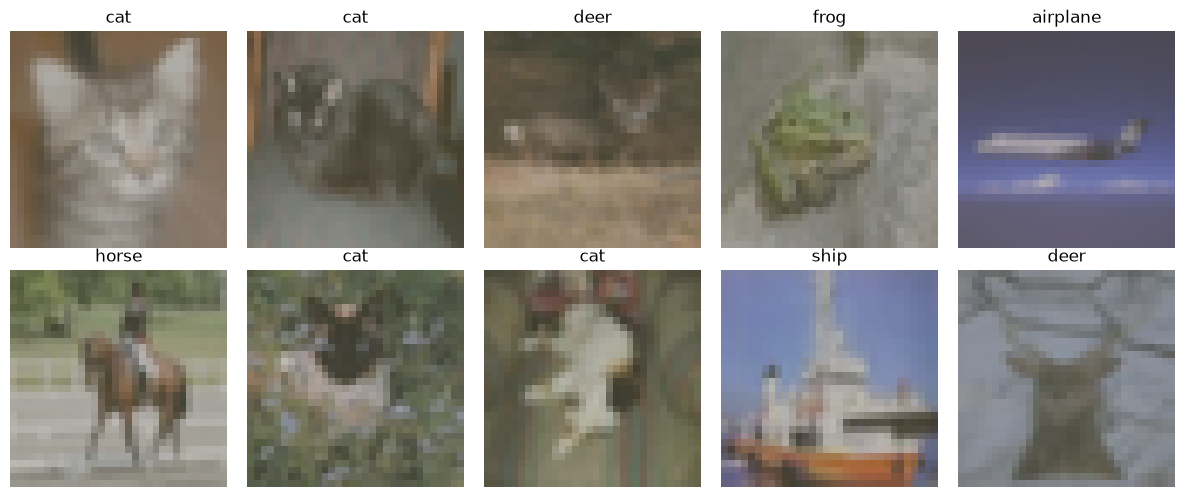

In [21]:
mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
std = torch.tensor([0.2470, 0.2435, 0.2616]).view(3, 1, 1)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for ax, img, label in zip(axes.flat, images[:10], labels[:10]):
    img_display = (img.cpu() * std + mean).clamp(0, 1)
    ax.imshow(img_display.permute(1, 2, 0))
    ax.set_title(classes[label.item()])
    ax.axis("off")

plt.tight_layout()
plt.show()


### Explication

Le tenseur PyTorch est organisé en **C × H × W**, alors que Matplotlib attend **H × W × C**.

C'est pourquoi :

`permute(1, 2, 0)`

change l'ordre des dimensions.

### Réflexe formateur
Toujours regarder quelques observations avant d'entraîner un modèle. Cela permet de vérifier que les images, les labels et les transformations sont cohérents.


# 6. Première approche : un MLP sur l'image aplatie

Nous allons volontairement commencer par un réseau dense afin de comprendre pourquoi le CNN est mieux adapté à l'image.


In [22]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Flatten(),
            nn.Linear(3 * 32 * 32, 512),
            nn.ReLU(),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.network(x)

mlp = MLP().to(device)
print(mlp)


MLP(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3072, out_features=512, bias=True)
    (2): ReLU()
    (3): Linear(in_features=512, out_features=128, bias=True)
    (4): ReLU()
    (5): Linear(in_features=128, out_features=10, bias=True)
  )
)


### Explication détaillée

**`class MLP(nn.Module)`** définit un modèle PyTorch.

**`super().__init__()`** initialise correctement la classe parent `nn.Module`.

**`nn.Flatten()`** transforme chaque image `3 × 32 × 32` en un vecteur de `3072` valeurs.

**`nn.Linear(3072, 512)`** crée une couche dense avec 3072 entrées et 512 neurones.

**`nn.ReLU()`** ajoute la non-linéarité.

La deuxième couche réduit la représentation de 512 à 128 valeurs.

La dernière couche produit **10 scores**, un pour chaque classe CIFAR-10.

### Pourquoi n'y a-t-il pas `Softmax` ?
`CrossEntropyLoss` attend directement les **logits** et applique en interne l'opération appropriée. Ajouter un Softmax ici serait inutile.

### Limite du MLP
L'image est aplatie. La structure spatiale est donc beaucoup moins explicitement exploitée.


# 7. Observer un forward pass

Avant d'entraîner, vérifions que les dimensions sont correctes.


In [23]:
batch_images, batch_labels = next(iter(train_loader))
batch_images = batch_images.to(device)

with torch.no_grad():
    logits = mlp(batch_images)

print("Entrée :", batch_images.shape)
print("Sortie :", logits.shape)
print("Exemple de logits :", logits[0])


Entrée : torch.Size([128, 3, 32, 32])
Sortie : torch.Size([128, 10])
Exemple de logits : tensor([ 0.0415,  0.0213, -0.0201,  0.0054,  0.0336,  0.0031, -0.0894, -0.1125,
         0.0266,  0.1571])


### Explication

Le mini-batch contient 128 images.

Le réseau retourne une matrice de taille :

`[128, 10]`

Chaque ligne correspond à une image et contient dix scores.

Le modèle n'est pas encore entraîné : les scores n'ont donc aucune raison d'être pertinents.

**`torch.no_grad()`** indique que nous ne voulons pas construire le graphe de gradients pour cette simple vérification.

### À retenir
Le **forward** calcule la sortie du réseau. Il ne met pas encore les poids à jour.


# 8. Loss et optimiseur

Nous préparons maintenant le mécanisme d'apprentissage.


In [24]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    mlp.parameters(),
    lr=1e-3
)

print(criterion)
print(optimizer)


CrossEntropyLoss()
Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


### Explication

**`CrossEntropyLoss`** est adaptée à une classification multiclasse à classes exclusives.

Elle compare les logits du réseau aux vrais labels.

**`Adam`** est l'algorithme qui mettra les paramètres à jour à partir des gradients.

**`mlp.parameters()`** transmet à Adam tous les poids et biais entraînables du réseau.

**`lr=1e-3`** correspond au learning rate.

### Le lien avec le cours
La mise à jour conceptuelle reste :

`paramètre ← paramètre − learning_rate × gradient`

Adam utilise une version plus sophistiquée de cette idée.


# 9. Une seule étape d'apprentissage, décomposée

Ce bloc est essentiel : il montre exactement le cycle **forward → loss → backward → update**.


In [25]:
mlp.train()

images_one, labels_one = next(iter(train_loader))
images_one = images_one.to(device)
labels_one = labels_one.to(device)

optimizer.zero_grad()          # 1. remettre les gradients à zéro
outputs = mlp(images_one)      # 2. forward
loss = criterion(outputs, labels_one)  # 3. calcul de la loss
loss.backward()                # 4. backpropagation
optimizer.step()               # 5. mise à jour des poids

print("Loss du mini-batch :", loss.item())


Loss du mini-batch : 2.311931848526001


### Explication — bloc à faire retenir

**1. `optimizer.zero_grad()`**  
PyTorch accumule les gradients. Nous les remettons donc à zéro avant le nouveau mini-batch.

**2. `outputs = mlp(images_one)`**  
C'est la **forward propagation**. Les images traversent toutes les couches.

**3. `criterion(outputs, labels_one)`**  
Nous comparons les prédictions aux vraies classes.

**4. `loss.backward()`**  
C'est la **backpropagation**. PyTorch calcule automatiquement le gradient de la loss par rapport à chaque paramètre entraînable.

**5. `optimizer.step()`**  
Adam utilise ces gradients pour modifier les poids.

### Phrase à retenir
**Forward produit la prédiction ; backward calcule les gradients ; optimizer.step modifie les paramètres.**


# 10. Fonction générique d'entraînement

Nous encapsulons maintenant ce mécanisme pour entraîner plusieurs époques.


In [26]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)

        predictions = outputs.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total


### Explication

**`model.train()`** place le réseau en mode entraînement. Cela devient particulièrement important avec des couches comme Dropout ou BatchNorm.

La boucle parcourt tous les mini-batches du DataLoader.

`loss.item() * images.size(0)` permet d'accumuler correctement la loss sur toutes les observations.

**`outputs.argmax(dim=1)`** choisit la classe ayant le logit le plus élevé.

Nous calculons ensuite l'accuracy TRAIN.

### Important
Cette fonction modifie le modèle parce qu'elle appelle :
- `loss.backward()`
- `optimizer.step()`.


# 11. Fonction d'évaluation

Pendant VALIDATION ou TEST, aucun poids ne doit être modifié.


In [28]:
def evaluate(model, loader, criterion, device):
    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            predictions = outputs.argmax(dim=1)

            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    return total_loss / total, correct / total


### Différence avec l'entraînement

**`model.eval()`** active le mode évaluation.

**`torch.no_grad()`** désactive le calcul des gradients.

Il n'y a ni `backward()` ni `optimizer.step()`.

Donc VALIDATION et TEST servent uniquement à **mesurer**.

### Réflexe anti-leakage
On ne modifie jamais les poids à partir du TEST.


# 12. Entraîner rapidement le MLP

Pour une démonstration en cours, quelques époques suffisent à observer la dynamique.


In [29]:
epochs = 3

history_mlp = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(
        mlp, train_loader, criterion, optimizer, device
    )

    val_loss, val_acc = evaluate(
        mlp, val_loader, criterion, device
    )

    history_mlp["train_loss"].append(train_loss)
    history_mlp["val_loss"].append(val_loss)
    history_mlp["train_acc"].append(train_acc)
    history_mlp["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"train loss={train_loss:.4f} | "
        f"train acc={train_acc:.4f} | "
        f"val loss={val_loss:.4f} | "
        f"val acc={val_acc:.4f}"
    )


Epoch 1/3 | train loss=1.6528 | train acc=0.4134 | val loss=1.5426 | val acc=0.4542
Epoch 2/3 | train loss=1.4399 | train acc=0.4913 | val loss=1.4666 | val acc=0.4849
Epoch 3/3 | train loss=1.3320 | train acc=0.5317 | val loss=1.4034 | val acc=0.5147


### Comment lire les résultats ?

Si TRAIN et VALIDATION s'améliorent ensemble, l'apprentissage progresse.

Si TRAIN devient très bon mais VALIDATION stagne ou se dégrade, nous observons probablement de l'**overfitting**.

Si TRAIN et VALIDATION restent tous les deux faibles, le modèle peut être en **underfitting** ou nécessiter davantage d'entraînement.

### Question aux étudiants
Pourquoi un MLP peut-il être limité ici malgré plusieurs couches ?

Réponse attendue : parce qu'il traite essentiellement l'image comme un vecteur et n'exploite pas naturellement les motifs locaux et le partage spatial des poids.


# 13. Construire un CNN

Nous conservons les images sous leur forme `[C, H, W]`.


In [30]:
class SmallCNN(nn.Module):
    def __init__(self, n_classes=10):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 128),
            nn.ReLU(),
            nn.Dropout(0.30),
            nn.Linear(128, n_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

cnn = SmallCNN().to(device)
print(cnn)


SmallCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4096, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)


### Explication détaillée de l'architecture

Entrée : **`3 × 32 × 32`**.

### Premier bloc
`Conv2d(3, 32, 3, padding=1)`  
→ 32 feature maps, dimensions spatiales conservées : `32 × 32`.

`ReLU()`  
→ non-linéarité.

`MaxPool2d(2)`  
→ dimensions divisées par deux : `16 × 16`.

### Deuxième bloc
La deuxième convolution transforme 32 canaux en 64 canaux.

Après le deuxième pooling :
`64 × 8 × 8`.

### Classifier
`Flatten()` transforme ce tenseur en vecteur de :

`64 × 8 × 8 = 4096` valeurs.

La couche dense réduit ensuite 4096 vers 128, puis 128 vers 10 classes.

**`Dropout(0.30)`** désactive aléatoirement une partie des activations pendant TRAIN afin de réduire la dépendance excessive à certains neurones.

### Différence fondamentale avec le MLP
Le CNN apprend des **filtres locaux partagés spatialement**.


# 14. Vérifier les dimensions du CNN

Une bonne habitude de développeur consiste à inspecter les shapes avant l'entraînement.


In [31]:
sample = images[:4].to(device)

with torch.no_grad():
    z = sample

    for i, layer in enumerate(cnn.features):
        z = layer(z)
        print(f"Après {i:02d} {layer.__class__.__name__:12s} -> {tuple(z.shape)}")

    logits = cnn(sample)

print("Sortie finale :", tuple(logits.shape))


Après 00 Conv2d       -> (4, 32, 32, 32)
Après 01 ReLU         -> (4, 32, 32, 32)
Après 02 MaxPool2d    -> (4, 32, 16, 16)
Après 03 Conv2d       -> (4, 64, 16, 16)
Après 04 ReLU         -> (4, 64, 16, 16)
Après 05 MaxPool2d    -> (4, 64, 8, 8)
Sortie finale : (4, 10)


### Pourquoi ce bloc est utile ?

Il permet de suivre la transformation du tenseur couche après couche.

Vous devez observer notamment :

`3 × 32 × 32`
→ convolution
→ `32 × 32 × 32`
→ pooling
→ `32 × 16 × 16`
→ deuxième convolution
→ `64 × 16 × 16`
→ pooling
→ `64 × 8 × 8`.

### En pratique
Lorsqu'une erreur PyTorch indique que deux matrices ne peuvent pas être multipliées, inspecter les shapes est souvent le premier diagnostic à faire.


# 15. Entraîner le CNN

Même protocole que le MLP : seule l'architecture change.


In [32]:
cnn_criterion = nn.CrossEntropyLoss()
cnn_optimizer = torch.optim.Adam(cnn.parameters(), lr=1e-3)

epochs_cnn = 5

history_cnn = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}

for epoch in range(epochs_cnn):
    train_loss, train_acc = train_one_epoch(
        cnn, train_loader, cnn_criterion, cnn_optimizer, device
    )

    val_loss, val_acc = evaluate(
        cnn, val_loader, cnn_criterion, device
    )

    history_cnn["train_loss"].append(train_loss)
    history_cnn["val_loss"].append(val_loss)
    history_cnn["train_acc"].append(train_acc)
    history_cnn["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch+1}/{epochs_cnn} | "
        f"train loss={train_loss:.4f} | "
        f"train acc={train_acc:.4f} | "
        f"val loss={val_loss:.4f} | "
        f"val acc={val_acc:.4f}"
    )


Epoch 1/5 | train loss=1.5631 | train acc=0.4340 | val loss=1.2892 | val acc=0.5423
Epoch 2/5 | train loss=1.2367 | train acc=0.5613 | val loss=1.1199 | val acc=0.6046
Epoch 3/5 | train loss=1.0826 | train acc=0.6162 | val loss=0.9894 | val acc=0.6456
Epoch 4/5 | train loss=0.9822 | train acc=0.6512 | val loss=0.9373 | val acc=0.6700
Epoch 5/5 | train loss=0.8972 | train acc=0.6822 | val loss=0.9126 | val acc=0.6762


### Ce qu'il faut faire observer

Le code d'entraînement n'a pratiquement pas changé.

C'est un principe important de PyTorch : une fois qu'un modèle respecte l'interface `nn.Module`, la même boucle peut entraîner différentes architectures.

### Question
Qu'est-ce qui a réellement changé entre le MLP et le CNN ?

Principalement :
- la manière d'extraire les représentations ;
- le nombre et l'organisation des paramètres ;
- l'exploitation de la structure spatiale.


# 16. Courbes TRAIN / VALIDATION


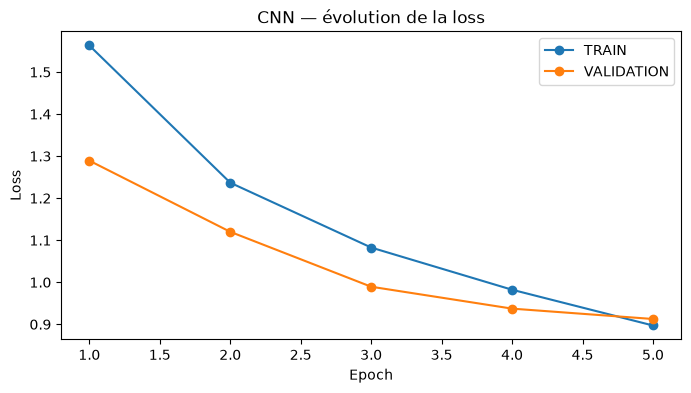

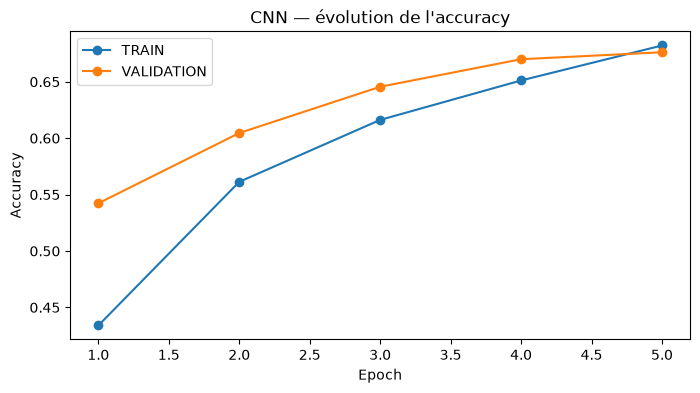

In [33]:
epochs_axis = range(1, len(history_cnn["train_loss"]) + 1)

plt.figure(figsize=(8, 4))
plt.plot(epochs_axis, history_cnn["train_loss"], marker="o", label="TRAIN")
plt.plot(epochs_axis, history_cnn["val_loss"], marker="o", label="VALIDATION")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN — évolution de la loss")
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(epochs_axis, history_cnn["train_acc"], marker="o", label="TRAIN")
plt.plot(epochs_axis, history_cnn["val_acc"], marker="o", label="VALIDATION")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN — évolution de l'accuracy")
plt.legend()
plt.show()


### Interprétation

Nous ne regardons jamais uniquement la dernière valeur.

Les courbes permettent de voir la **dynamique** de l'apprentissage.

Cas typiques :

- TRAIN faible + VALIDATION faible → underfitting ;
- TRAIN très élevé + VALIDATION nettement plus faible → overfitting ;
- TRAIN et VALIDATION progressent ensemble → apprentissage plus sain.

### Décision possible
Si VALIDATION commence à se dégrader pendant que TRAIN continue de s'améliorer, nous pouvons envisager un **early stopping**.


# 17. Évaluation finale du CNN sur TEST

Nous ouvrons maintenant TEST.


In [37]:
test_loss, test_acc = evaluate(
    cnn,
    test_loader,
    cnn_criterion,
    device
)

print(f"TEST loss     : {test_loss:.4f}")
print(f"TEST accuracy : {test_acc:.4f}")


TEST loss     : 0.9160
TEST accuracy : 0.6795


### Explication

TEST n'a pas servi à entraîner les poids ni à choisir les hyperparamètres.

Il fournit donc une estimation finale de la capacité de généralisation du modèle.

### Attention
Si nous regardons TEST après chaque modification d'architecture, TEST devient indirectement un jeu de validation. Il perd alors son rôle d'évaluation finale indépendante.


# 18. Matrice de confusion et métriques par classe


              precision    recall  f1-score   support

    airplane       0.73      0.72      0.73      1000
  automobile       0.79      0.81      0.80      1000
        bird       0.66      0.40      0.50      1000
         cat       0.48      0.54      0.51      1000
        deer       0.66      0.60      0.63      1000
         dog       0.60      0.57      0.58      1000
        frog       0.80      0.74      0.76      1000
       horse       0.68      0.81      0.74      1000
        ship       0.70      0.85      0.77      1000
       truck       0.72      0.76      0.74      1000

    accuracy                           0.68     10000
   macro avg       0.68      0.68      0.68     10000
weighted avg       0.68      0.68      0.68     10000



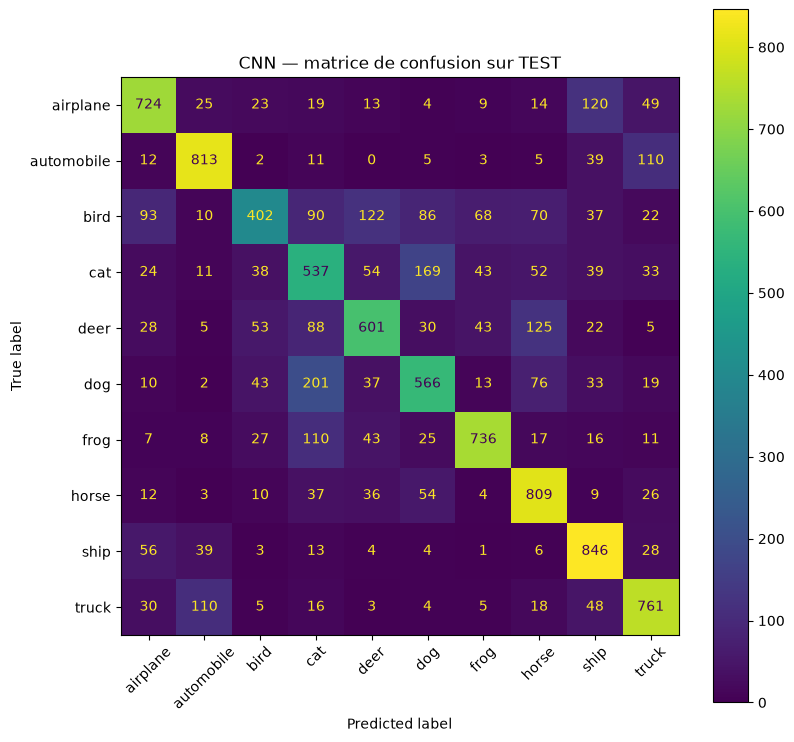

In [38]:
cnn.eval()

all_true = []
all_pred = []

with torch.no_grad():
    for images_batch, labels_batch in test_loader:
        images_batch = images_batch.to(device)

        outputs = cnn(images_batch)
        preds = outputs.argmax(dim=1).cpu()

        all_true.extend(labels_batch.numpy())
        all_pred.extend(preds.numpy())

print(classification_report(
    all_true,
    all_pred,
    target_names=classes,
    zero_division=0
))

cm = confusion_matrix(all_true, all_pred)

fig, ax = plt.subplots(figsize=(9, 9))
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
).plot(ax=ax, xticks_rotation=45)

plt.title("CNN — matrice de confusion sur TEST")
plt.show()


### Pourquoi l'accuracy ne suffit-elle pas ?

Une accuracy globale peut cacher des classes difficiles.

La matrice de confusion montre quelles classes sont confondues entre elles.

Le `classification_report` donne notamment précision, rappel et F1 par classe.

### Travail d'analyse
Chercher les couples de classes les plus souvent confondus et proposer une explication visuelle ou métier.


# 19. Afficher quelques erreurs du CNN


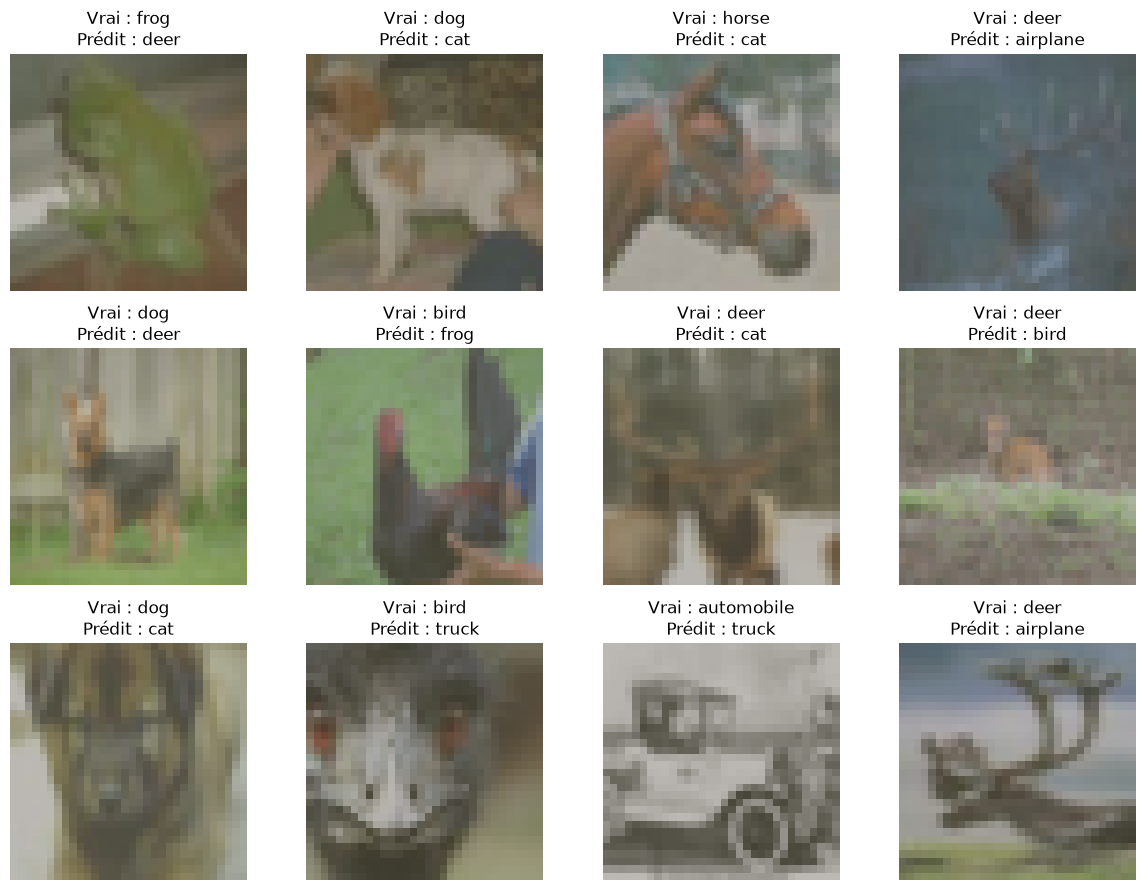

In [39]:
cnn.eval()

wrong_images = []
wrong_true = []
wrong_pred = []

with torch.no_grad():
    for images_batch, labels_batch in test_loader:
        outputs = cnn(images_batch.to(device))
        preds = outputs.argmax(dim=1).cpu()

        mask = preds != labels_batch

        for img, true_label, pred_label in zip(
            images_batch[mask],
            labels_batch[mask],
            preds[mask]
        ):
            wrong_images.append(img)
            wrong_true.append(true_label.item())
            wrong_pred.append(pred_label.item())

        if len(wrong_images) >= 12:
            break

fig, axes = plt.subplots(3, 4, figsize=(12, 9))

for ax, img, true_label, pred_label in zip(
    axes.flat,
    wrong_images[:12],
    wrong_true[:12],
    wrong_pred[:12]
):
    img_display = (img * std + mean).clamp(0, 1)
    ax.imshow(img_display.permute(1, 2, 0))
    ax.set_title(
        f"Vrai : {classes[true_label]}\n"
        f"Prédit : {classes[pred_label]}"
    )
    ax.axis("off")

plt.tight_layout()
plt.show()


### Analyse d'erreurs

Cette étape est essentielle.

Pour chaque erreur, demandez :
- l'objet est-il petit ?
- l'arrière-plan domine-t-il l'image ?
- les deux classes sont-elles visuellement proches ?
- l'image est-elle ambiguë même pour un humain ?
- le modèle semble-t-il utiliser un indice parasite ?

### Message important
Un modèle ne doit pas seulement être évalué par un chiffre. Les erreurs révèlent souvent ce qu'il faudrait améliorer dans les données, les transformations ou l'architecture.


# 20. Transfer learning avec ResNet18

Nous allons maintenant réutiliser un réseau déjà entraîné sur ImageNet.

> La première exécution peut télécharger les poids pré-entraînés.


In [40]:
from torchvision.models import resnet18, ResNet18_Weights

weights = ResNet18_Weights.DEFAULT
resnet = resnet18(weights=weights)

print("Dernière couche originale :")
print(resnet.fc)


Dernière couche originale :
Linear(in_features=512, out_features=1000, bias=True)


### Explication

`ResNet18_Weights.DEFAULT` demande les poids pré-entraînés recommandés.

`resnet18(weights=weights)` construit ResNet18 et charge ces paramètres.

Le réseau a appris sur ImageNet à reconnaître de nombreuses structures visuelles.

La dernière couche `fc` correspond au classifieur original ImageNet.

### Notre objectif
Conserver les représentations visuelles apprises par le backbone, mais remplacer la tête pour produire **10 classes CIFAR-10**.


# 21. Geler le backbone et remplacer la tête


In [41]:
for parameter in resnet.parameters():
    parameter.requires_grad = False

in_features = resnet.fc.in_features

resnet.fc = nn.Linear(
    in_features,
    len(classes)
)

resnet = resnet.to(device)

trainable = sum(
    p.numel()
    for p in resnet.parameters()
    if p.requires_grad
)

total = sum(p.numel() for p in resnet.parameters())

print("Paramètres totaux       :", total)
print("Paramètres entraînables :", trainable)
print(resnet.fc)


Paramètres totaux       : 11181642
Paramètres entraînables : 5130
Linear(in_features=512, out_features=10, bias=True)


### Explication

La boucle place `requires_grad=False` sur les paramètres du backbone.

Cela signifie que nous ne voulons pas calculer ni appliquer de mises à jour sur ces poids.

Nous récupérons ensuite le nombre d'entrées de la couche `fc` originale.

Puis nous remplaçons cette couche par :

`nn.Linear(in_features, 10)`

Cette nouvelle couche est créée **après** le gel du backbone. Elle reste donc entraînable.

### Résultat
La très grande majorité du réseau est réutilisée telle quelle. Seule la nouvelle tête apprend notre tâche.


# 22. Transformations adaptées au modèle pré-entraîné

Un modèle pré-entraîné attend un format d'entrée cohérent avec son pré-entraînement.


In [43]:
CIFAR_ROOT = r"../data/cifar-10-python"

transfer_train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    )
])

transfer_eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    )
])

transfer_train_full = datasets.CIFAR10(
    root=CIFAR_ROOT,
    train=True,
    download=False,
    transform=transfer_train_transform
)

transfer_eval_full = datasets.CIFAR10(
    root=CIFAR_ROOT,
    train=True,
    download=False,
    transform=transfer_eval_transform
)

transfer_test = datasets.CIFAR10(
    root=CIFAR_ROOT,
    train=False,
    download=False,
    transform=transfer_eval_transform
)

train_indices = train_dataset.indices
val_indices = val_dataset.indices

transfer_train = torch.utils.data.Subset(
    transfer_train_full,
    train_indices
)

transfer_val = torch.utils.data.Subset(
    transfer_eval_full,
    val_indices
)

print("Transfer TRAIN :", len(transfer_train))
print("Transfer VALID :", len(transfer_val))
print("Transfer TEST  :", len(transfer_test))

Transfer TRAIN : 40000
Transfer VALID : 10000
Transfer TEST  : 10000


### Explication

ResNet18 pré-entraîné utilise les conventions ImageNet.

Nous redimensionnons donc les images vers `224 × 224` et utilisons la normalisation ImageNet.

Sur TRAIN, nous ajoutons `RandomHorizontalFlip()` : c'est une petite augmentation de données.

Sur VALIDATION et TEST, il n'y a pas d'augmentation aléatoire.

### Point important
Nous réutilisons exactement les mêmes indices TRAIN et VALIDATION que précédemment. Seules les transformations changent.

### Pourquoi ?
Cela rend la comparaison plus propre et évite qu'une différence de split soit confondue avec une différence de modèle.


# 23. DataLoaders pour le transfer learning


In [44]:
transfer_train_loader = DataLoader(
    transfer_train,
    batch_size=64,
    shuffle=True,
    num_workers=0
)

transfer_val_loader = DataLoader(
    transfer_val,
    batch_size=64,
    shuffle=False,
    num_workers=0
)

transfer_test_loader = DataLoader(
    transfer_test,
    batch_size=64,
    shuffle=False,
    num_workers=0
)

x_transfer, y_transfer = next(iter(transfer_train_loader))

print("Shape transfer :", x_transfer.shape)
print("Labels         :", y_transfer.shape)


Shape transfer : torch.Size([64, 3, 224, 224])
Labels         : torch.Size([64])


### Lecture

Les images ont maintenant la forme :

`[batch, 3, 224, 224]`

au lieu de :

`[batch, 3, 32, 32]`.

Le batch est également réduit à 64 car ResNet18 sur des images 224 × 224 consomme davantage de mémoire.

### En production
Le preprocessing fait partie du modèle opérationnel. Un modèle entraîné avec une normalisation donnée doit recevoir le même type de transformation au moment de l'inférence.


# 24. Entraîner uniquement la tête de ResNet18

Pour une démonstration en classe, une époque suffit à montrer le mécanisme. Vous pouvez augmenter cette valeur si vous disposez d'un GPU et de temps.


In [ ]:
transfer_criterion = nn.CrossEntropyLoss()

transfer_optimizer = torch.optim.Adam(
    resnet.fc.parameters(),
    lr=1e-3
)

transfer_epochs = 1

for epoch in range(transfer_epochs):
    train_loss, train_acc = train_one_epoch(
        resnet,
        transfer_train_loader,
        transfer_criterion,
        transfer_optimizer,
        device
    )

    val_loss, val_acc = evaluate(
        resnet,
        transfer_val_loader,
        transfer_criterion,
        device
    )

    print(
        f"Epoch {epoch+1}/{transfer_epochs} | "
        f"train loss={train_loss:.4f} | "
        f"train acc={train_acc:.4f} | "
        f"val loss={val_loss:.4f} | "
        f"val acc={val_acc:.4f}"
    )


### Ce qui se passe réellement

Le forward traverse tout ResNet18.

Mais les paramètres du backbone ont `requires_grad=False`.

L'optimiseur reçoit uniquement :

`resnet.fc.parameters()`

Il ne met donc à jour que la nouvelle tête.

### C'est le premier niveau du transfer learning
**Feature extraction** : le backbone est utilisé comme extracteur de caractéristiques fixe.


# 25. Fine-tuning : dégeler une partie du réseau

Après l'entraînement de la tête, on peut adapter les dernières couches du backbone avec un learning rate plus faible.


In [ ]:
for parameter in resnet.layer4.parameters():
    parameter.requires_grad = True

fine_tune_optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, resnet.parameters()),
    lr=1e-4
)

trainable_after_unfreeze = sum(
    p.numel()
    for p in resnet.parameters()
    if p.requires_grad
)

print(
    "Paramètres entraînables après dégel de layer4 :",
    trainable_after_unfreeze
)


### Explication

Nous ne dégelons pas immédiatement tout le réseau.

Ici, nous dégelons uniquement `layer4`, c'est-à-dire une partie profonde de ResNet18.

Pourquoi les dernières couches ?

Les premières couches apprennent généralement des caractéristiques assez générales. Les couches profondes sont davantage spécialisées.

Nous utilisons également un learning rate plus faible : `1e-4`.

### Pourquoi ?
Nous ne voulons pas détruire brutalement les représentations utiles déjà apprises pendant le pré-entraînement.

Cette deuxième phase s'appelle le **fine-tuning**.


# 26. Comparaison finale à construire

Le but n'est pas seulement de dire « ResNet est meilleur ». Il faut comparer plusieurs dimensions.


In [ ]:
comparison_template = {
    "Modèle": [
        "MLP",
        "CNN from scratch",
        "ResNet18 transfer learning"
    ],
    "Structure spatiale": [
        "Faible",
        "Oui",
        "Oui"
    ],
    "Pré-entraîné": [
        "Non",
        "Non",
        "Oui"
    ],
    "Coût entraînement": [
        "Faible à moyen",
        "Moyen",
        "Variable"
    ]
}

import pandas as pd

display(pd.DataFrame(comparison_template))


### Discussion à mener

**MLP**  
Simple et pédagogique, mais il exploite mal la structure spatiale.

**CNN from scratch**  
Apprend ses propres filtres à partir du dataset.

**ResNet18 pré-entraîné**  
Réutilise des représentations déjà apprises sur un grand corpus d'images.

### Questions aux étudiants
- Quel modèle nécessite le moins de connaissances préalables ?
- Quel modèle a le plus de paramètres ?
- Quel modèle choisir avec très peu d'images métier ?
- Quel modèle est le plus simple à déployer sur un petit appareil ?
- Une meilleure accuracy justifie-t-elle toujours une architecture plus lourde ?


# 27. SYNTHÈSE — ce que vous devez savoir expliquer

### Réseau de neurones
`x → combinaison linéaire → activation → couches → prédiction`

### Apprentissage
`forward → loss → backward → optimizer.step()`

### CNN
`convolution → activation → pooling → représentations → classifier`

### Transfer learning
`modèle pré-entraîné → nouvelle tête → freeze → entraînement → fine-tuning éventuel`

### Réflexes d'ingénieur ML
1. vérifier les dimensions des tenseurs ;
2. séparer TRAIN / VALIDATION / TEST ;
3. ne pas entraîner sur TEST ;
4. observer les courbes d'apprentissage ;
5. analyser les erreurs ;
6. comparer performance, coût et robustesse ;
7. être capable d'expliquer chaque ligne importante du pipeline.

---

## Questions flash de fin de cours

1. Pourquoi une activation non linéaire est-elle nécessaire ?
2. Quelle différence entre `loss.backward()` et `optimizer.step()` ?
3. Pourquoi un CNN est-il plus naturel qu'un MLP pour une image ?
4. Que signifie un filtre de convolution ?
5. Quel est le rôle du pooling ?
6. Pourquoi vérifier les shapes ?
7. Quelle différence entre feature extraction et fine-tuning ?
8. Pourquoi TEST doit-il rester fermé jusqu'à la fin ?
